Radon exposure across Canadian FSAs:

Is highly skewed.

Shows density concentrations in two ranges.

Does NOT form discrete clusters.

Is NOT primarily driven by sampling instability.

Reflects real environmental heterogeneity.

The variation is continuous, structured, and persistent.

NOw, we need to figure out what explains the variation...


In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import re

In [ ]:

Path.cwd()
PROJECT_ROOT = Path.cwd().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "final_dataset" / "main_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.shape

In [ ]:

def clean_column_name(col: str) -> str:
    col = col.strip().lower()
    
    # Replace common separators with underscore
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    col = col.replace("/", "_")
    
    # Remove parentheses and commas
    col = re.sub(r"[(),]", "", col)
    
    # Remove any character that is not alphanumeric or underscore
    col = re.sub(r"[^a-z0-9_]", "", col)
    
    # Collapse multiple underscores
    col = re.sub(r"_+", "_", col)
    
    # Remove leading/trailing underscores
    col = col.strip("_")
    
    return col

df.columns = [clean_column_name(c) for c in df.columns]

df.columns.tolist()

['fsa',
 'n_days',
 'concentration',
 'longitude',
 'latitude',
 'pct_single_detached',
 'pct_highrise',
 'pct_other_attached',
 'pct_movable',
 'avg_rooms',
 'pct_major_repair',
 'pct_pre_1980',
 'pct_1981_2000',
 'pct_post_2001',
 'median_home_value',
 'pop_2016',
 'num_dwellings',
 'occ_dwellings',
 'median_age',
 'avg_household_size',
 'pct_owned',
 'pct_rented',
 'pct_band',
 'pct_low_income',
 'med_income',
 'pct_high_income',
 'pct_govt_transfers',
 'unemployment_rate',
 'pct_non_laborer',
 'pct_bachelor_plus',
 'pct_overcrowded',
 'pct_unsuitable_housing',
 'pct_housing_poor_owners',
 'rxtp_intrusive_rocks',
 'rxtp_metamorphic_rocks',
 'rxtp_sedimentary_and_volcanic_rocks',
 'rxtp_sedimentary_rocks',
 'rxtp_unknown',
 'rxtp_volcanic_rocks',
 'geolprov_appalachian_orogen',
 'geolprov_arctic_continental_shelf',
 'geolprov_arctic_platform',
 'geolprov_atlantic_continental_shelf',
 'geolprov_bear_province',
 'geolprov_churchill_province',
 'geolprov_cordilleran_orogen',
 'geolprov_

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13077 entries, 0 to 13076
Data columns (total 76 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   fsa                                  13077 non-null  str    
 1   n_days                               13077 non-null  float64
 2   concentration                        13077 non-null  float64
 3   longitude                            13077 non-null  float64
 4   latitude                             13077 non-null  float64
 5   pct_single_detached                  13077 non-null  float64
 6   pct_highrise                         13077 non-null  float64
 7   pct_other_attached                   13077 non-null  float64
 8   pct_movable                          13077 non-null  float64
 9   avg_rooms                            13077 non-null  float64
 10  pct_major_repair                     13077 non-null  float64
 11  pct_pre_1980                         13

In [21]:
df.isna().sum().sort_values(ascending=False).head(10)

max_uranium            3121
mean_uranium           3121
fsa                       0
n_days                    0
latitude                  0
pct_single_detached       0
pct_highrise              0
pct_other_attached        0
pct_movable               0
avg_rooms                 0
dtype: int64

In [15]:
df[df["mean_uranium"].isna()]["fsa"].value_counts()

fsa
G8P    143
V0C    102
V0N     77
G0C     68
V8G     66
      ... 
V7R      2
V8N      2
V8R      2
V8X      2
V9S      2
Name: count, Length: 346, dtype: int64

In [16]:
df[df["mean_uranium"].isna()]["provinceterritory"].value_counts()

provinceterritory
BC    1377
QC     778
ON     460
NL     163
NB     134
AB     121
MB      48
SK      21
NS      19
Name: count, dtype: int64

In [23]:
df["concentration"].describe()

count    13077.000000
mean        96.444636
std        168.876977
min          7.500000
25%         19.000000
50%         48.000000
75%        115.000000
max       5657.000000
Name: concentration, dtype: float64

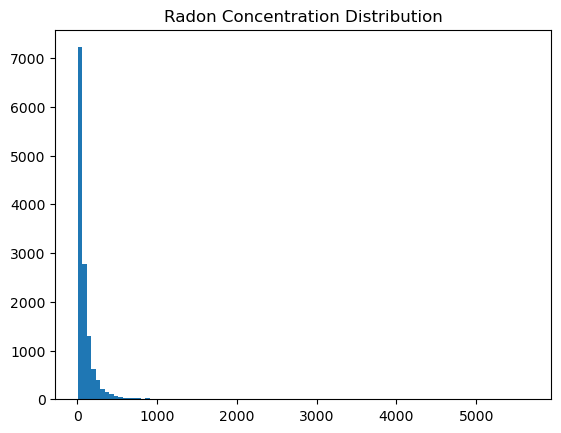

In [24]:
plt.hist(df["concentration"], bins=100)
plt.title("Radon Concentration Distribution")
plt.show()

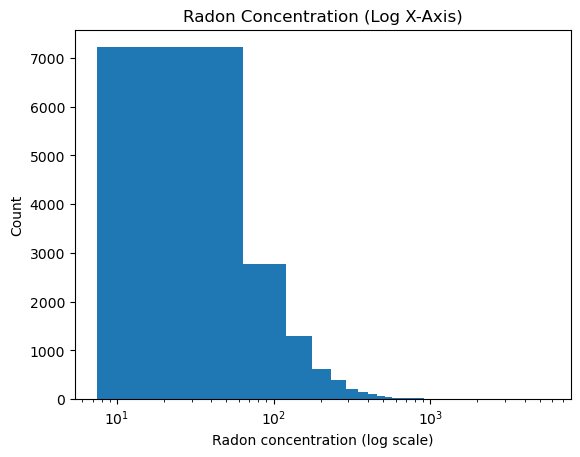

In [25]:

plt.hist(df["concentration"], bins=100)
plt.xscale("log")
plt.xlabel("Radon concentration (log scale)")
plt.ylabel("Count")
plt.title("Radon Concentration (Log X-Axis)")
plt.show()

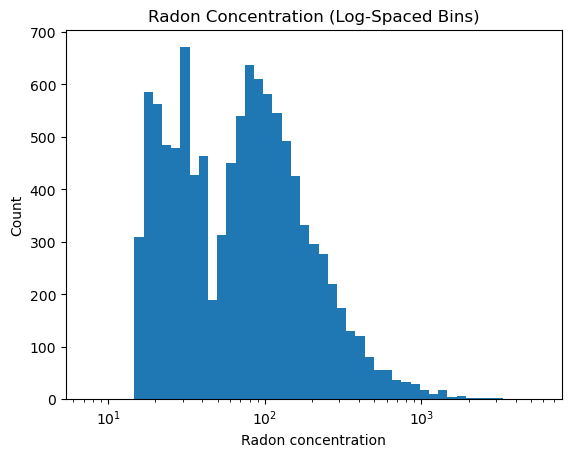

In [29]:

x = df["concentration"]

# Define log-spaced bins
bins = np.logspace(
    np.log10(x.min()),
    np.log10(x.max()),
    50
)

plt.hist(x, bins=bins)
plt.xscale("log")
plt.xlabel("Radon concentration")
plt.ylabel("Count")
plt.title("Radon Concentration (Log-Spaced Bins)")
plt.show()

interesting bi-modal:  mitigation? two classes of geology?  housing?

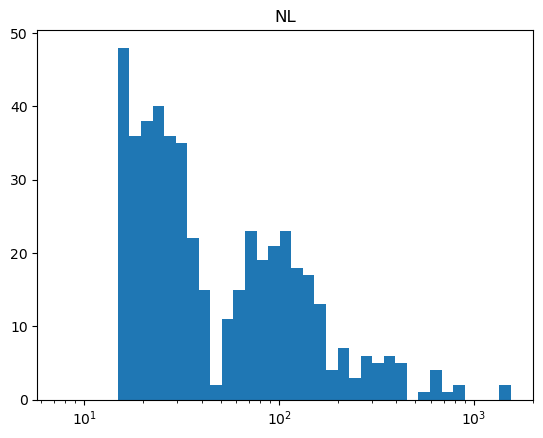

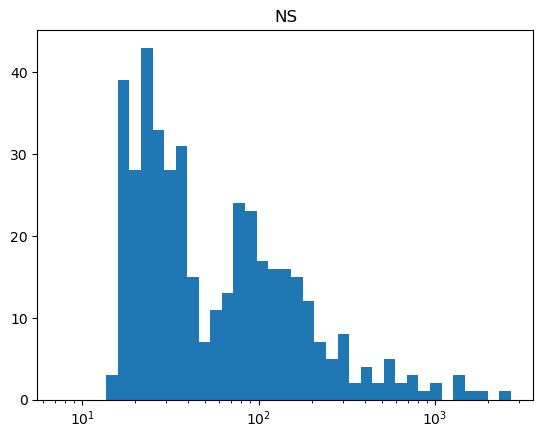

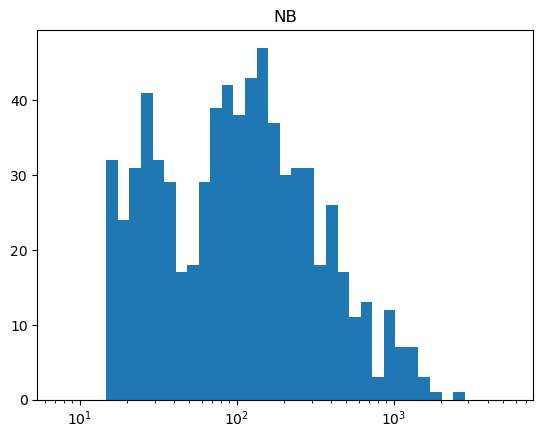

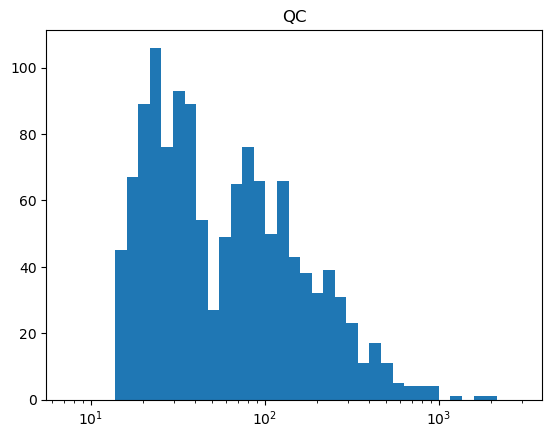

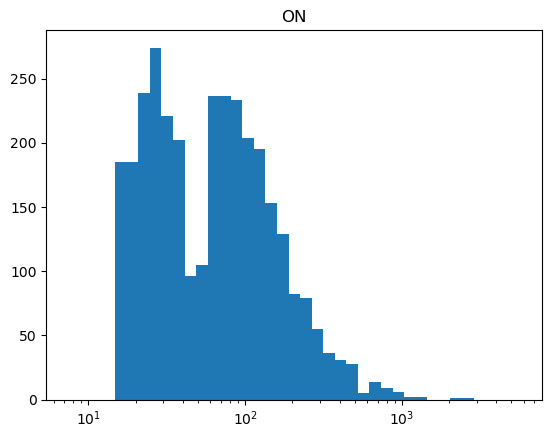

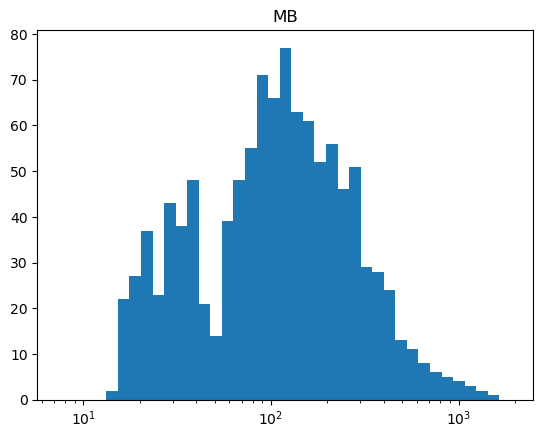

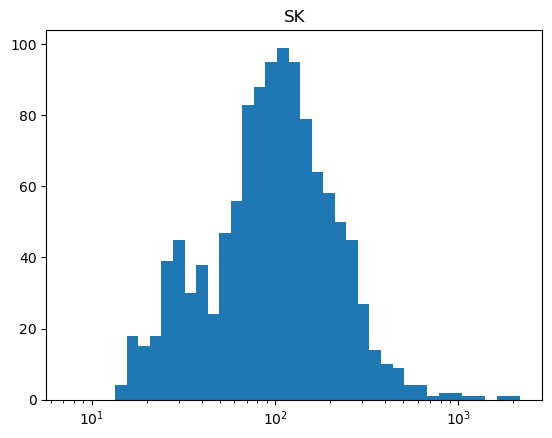

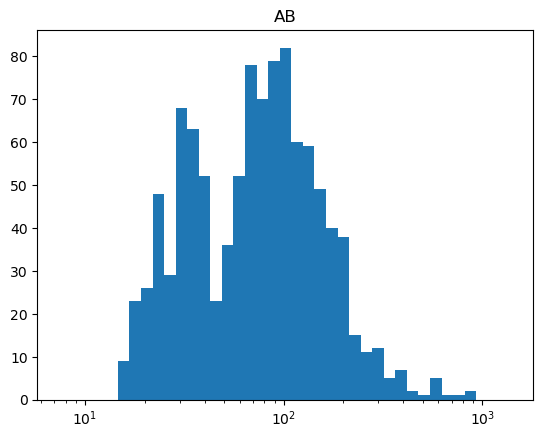

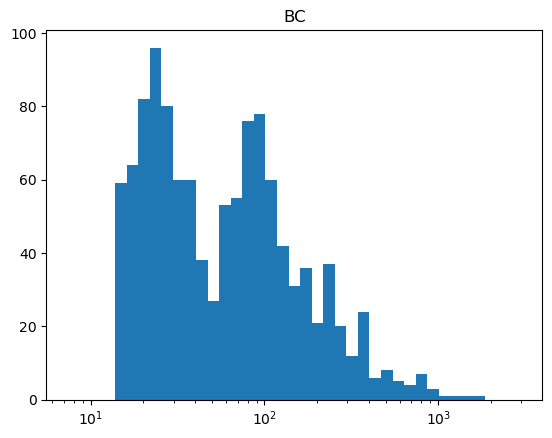

In [30]:
import numpy as np
import matplotlib.pyplot as plt

provinces = df["provinceterritory"].unique()

for p in provinces:
    subset = df[df["provinceterritory"] == p]["concentration"]
    
    if len(subset) > 200:  # avoid tiny provinces
        bins = np.logspace(
            np.log10(subset.min()),
            np.log10(subset.max()),
            40
        )
        
        plt.figure()
        plt.hist(subset, bins=bins)
        plt.xscale("log")
        plt.title(f"{p}")
        plt.show()

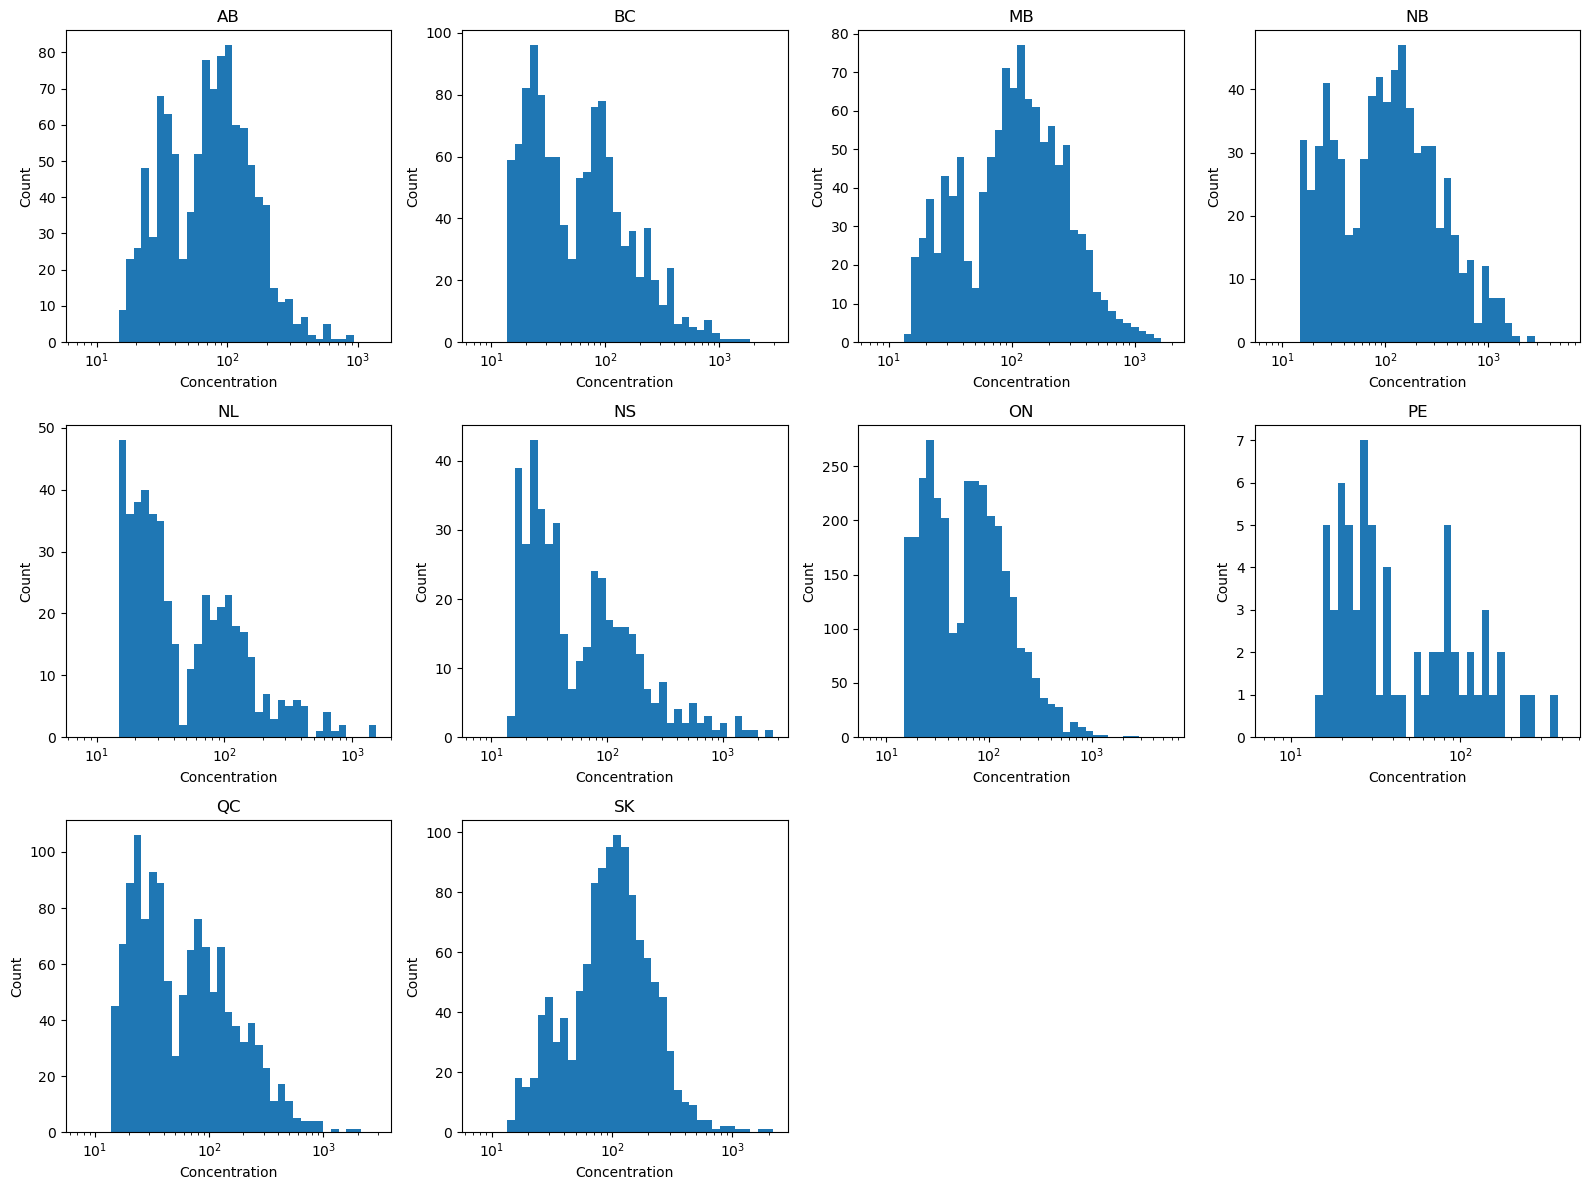

In [ ]:
provinces = sorted(df["provinceterritory"].unique())

n_prov = len(provinces)
ncols = 4
nrows = int(np.ceil(n_prov / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for i, prov in enumerate(provinces):
    ax = axes[i]
    subset = df[df["provinceterritory"] == prov]["concentration"]
    
    # Skip if too few observations
    if len(subset) < 50:
        ax.set_visible(False)
        continue
    
    bins = np.logspace(
        np.log10(subset.min()),
        np.log10(subset.max()),
        40
    )
    
    ax.hist(subset, bins=bins)
    ax.set_xscale("log")
    ax.set_title(prov)
    ax.set_xlabel("Concentration")
    ax.set_ylabel("Count")

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

bi-modality persists across provinces

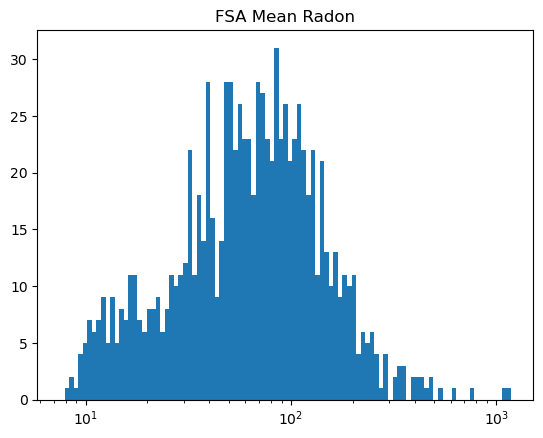

In [33]:
fsa_means = df.groupby("fsa")["concentration"].mean()

bins = np.logspace(
    np.log10(fsa_means.min()),
    np.log10(fsa_means.max()),
    100
)

plt.hist(fsa_means, bins=bins)
plt.xscale("log")
plt.title("FSA Mean Radon")
plt.show()

Bi-m,odality is still sorta there?

In [48]:
fsa_stats = df.groupby("fsa")["concentration"].agg(
    mean="mean",
    median="median",
    p80=lambda x: x.quantile(0.8),
    p90=lambda x: x.quantile(0.9),
    max="max",
    count="count"
)
fsa_stats["count"].describe()

count    1005.000000
mean       13.011940
std        19.112944
min         2.000000
25%         3.000000
50%         6.000000
75%        13.000000
max       175.000000
Name: count, dtype: float64

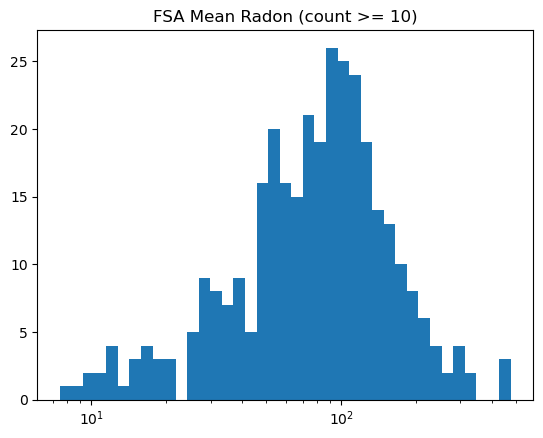

In [39]:
fsa_filtered = fsa_stats[fsa_stats["count"] >= 10]["mean"]


bins = np.logspace(
    np.log10(fsa_filtered.min()),
    np.log10(fsa_filtered.max()),
    40
)

plt.hist(fsa_filtered, bins=bins)
plt.xscale("log")
plt.title("FSA Mean Radon (count >= 10)")
plt.show()

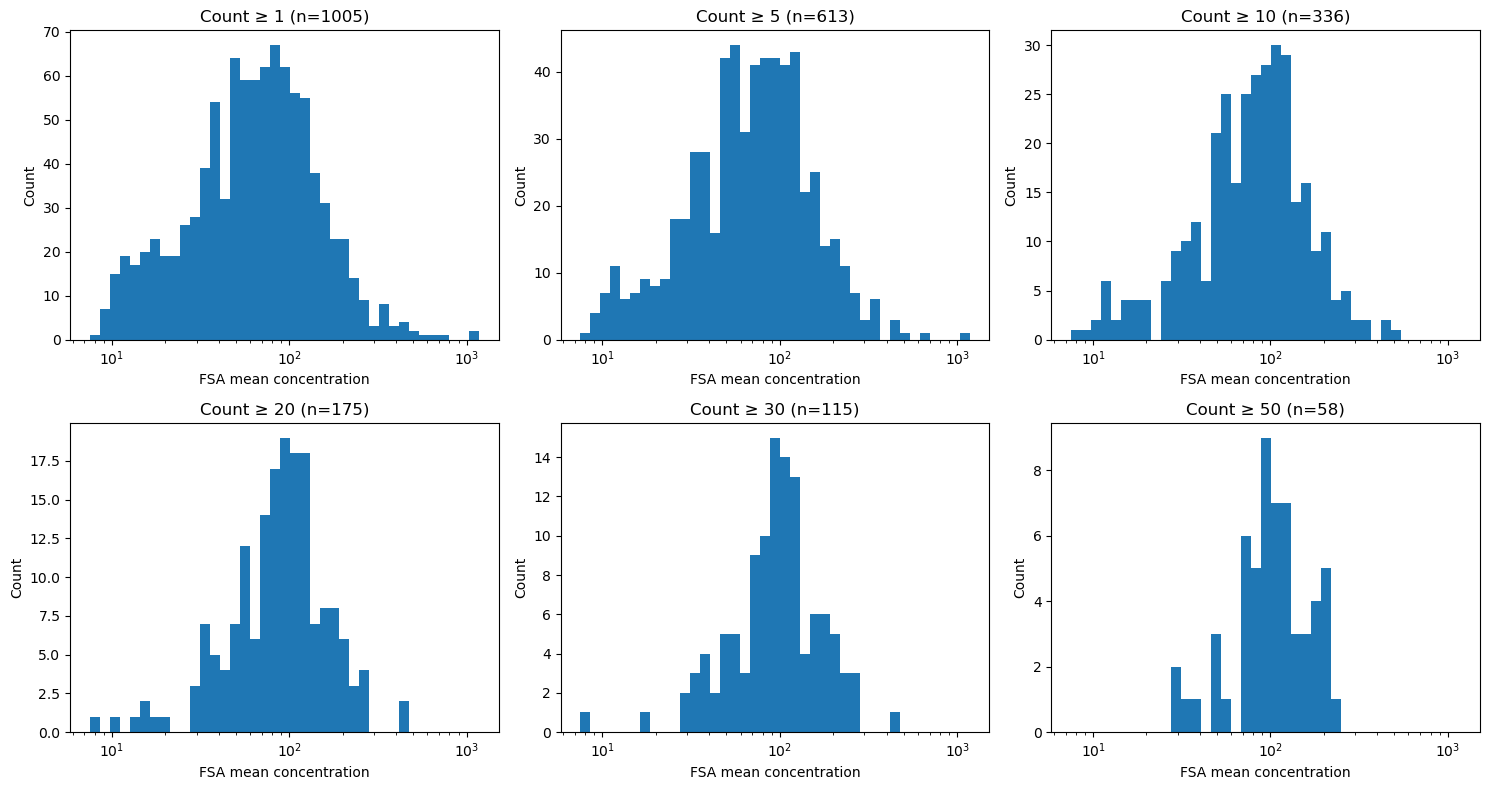

In [40]:
cutoffs = [1, 5, 10, 20, 30, 50]


all_means = fsa_stats["mean"]

bins = np.logspace(
    np.log10(all_means.min()),
    np.log10(all_means.max()),
    40
)


ncols = 3
nrows = int(np.ceil(len(cutoffs) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, cutoff in enumerate(cutoffs):
    ax = axes[i]
    
    subset = fsa_stats[fsa_stats["count"] >= cutoff]["mean"]
    
    ax.hist(subset, bins=bins)
    ax.set_xscale("log")
    ax.set_title(f"Count ≥ {cutoff} (n={len(subset)})")
    ax.set_xlabel("FSA mean concentration")
    ax.set_ylabel("Count")

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

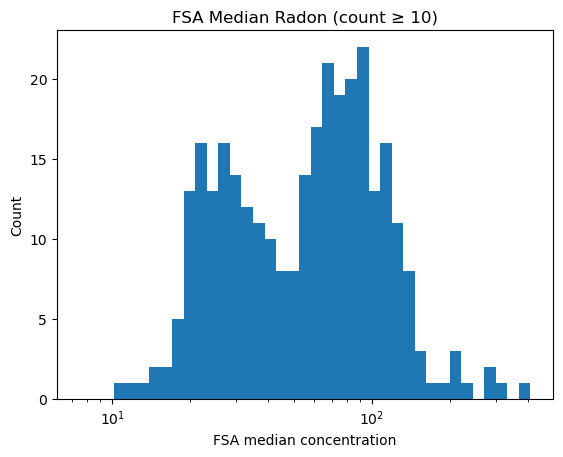

In [42]:
cutoff = 10
subset = fsa_stats[fsa_stats["count"] >= cutoff]["median"]

import numpy as np
import matplotlib.pyplot as plt

bins = np.logspace(
    np.log10(subset.min()),
    np.log10(subset.max()),
    40
)


plt.hist(subset, bins=bins)
plt.xscale("log")
plt.xlabel("FSA median concentration")
plt.ylabel("Count")
plt.title(f"FSA Median Radon (count ≥ {cutoff})")
plt.show()

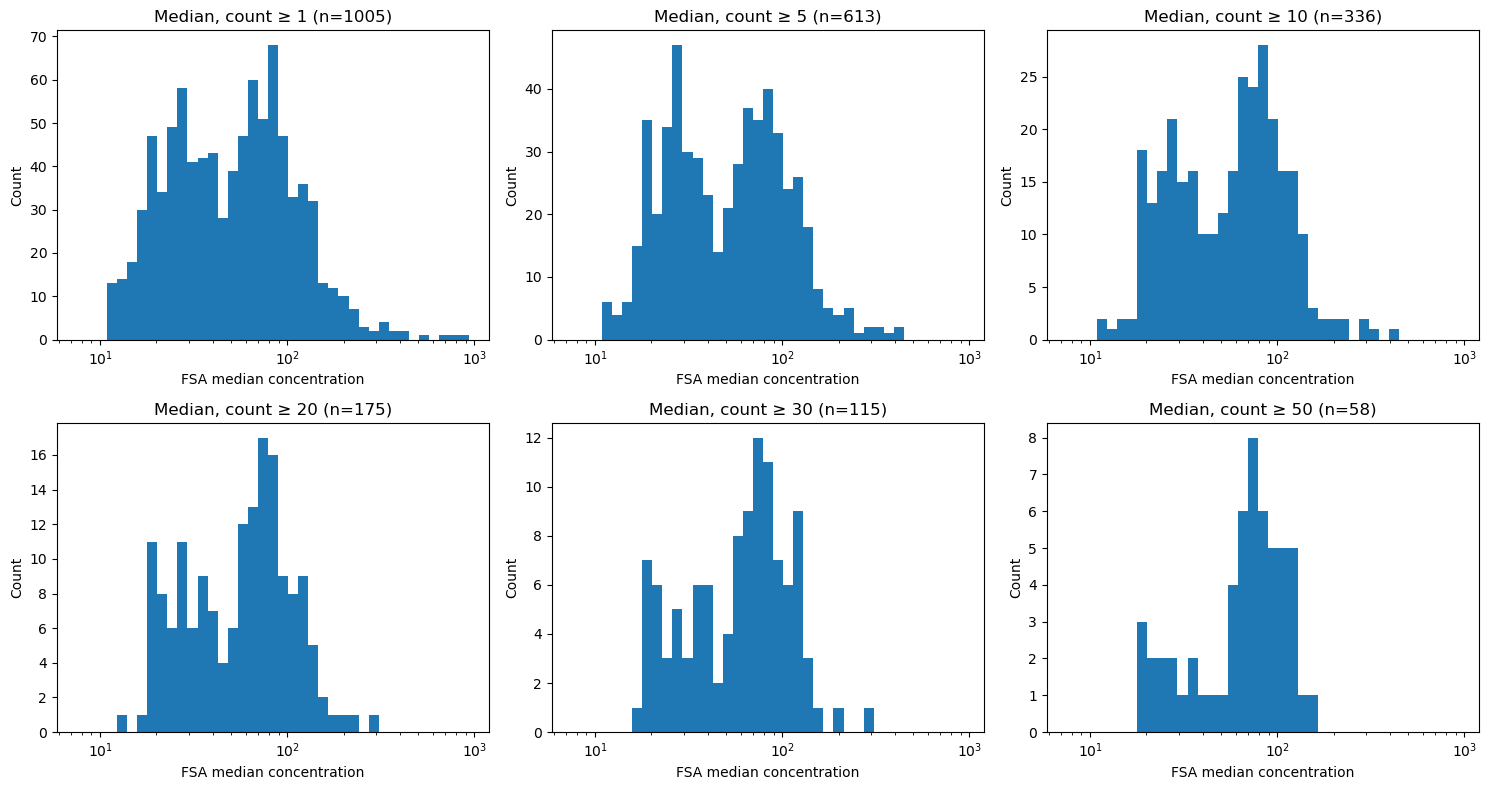

In [43]:
cutoffs = [1, 5, 10, 20, 30, 50]

all_medians = fsa_stats["median"]

bins = np.logspace(
    np.log10(all_medians.min()),
    np.log10(all_medians.max()),
    40
)

import matplotlib.pyplot as plt

ncols = 3
nrows = int(np.ceil(len(cutoffs) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, cutoff in enumerate(cutoffs):
    ax = axes[i]
    
    subset = fsa_stats[fsa_stats["count"] >= cutoff]["median"]
    
    ax.hist(subset, bins=bins)
    ax.set_xscale("log")
    ax.set_title(f"Median, count ≥ {cutoff} (n={len(subset)})")
    ax.set_xlabel("FSA median concentration")
    ax.set_ylabel("Count")

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

There are clearly two populations of homes in the FSAs!  This might give us a great cutoff for prediction!  middle of the two peaks is around 50

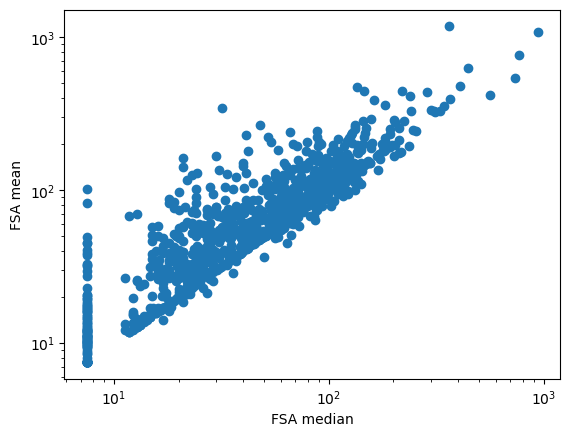

In [44]:
plt.scatter(fsa_stats["median"], fsa_stats["mean"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("FSA median")
plt.ylabel("FSA mean")
plt.show()

In [45]:
(fsa_stats["mean"] / fsa_stats["median"]).describe()

count    1005.000000
mean        1.566100
std         1.025258
min         0.710938
25%         1.000000
50%         1.254902
75%         1.744152
max        13.644444
dtype: float64

heavy right tails: occasional high-radon homes pull the mean up.  makes sense and means that we should pay special attention to tails of distribution (this sounds annoying...)... Let's look at the distribution of the upper percentiles in the data!

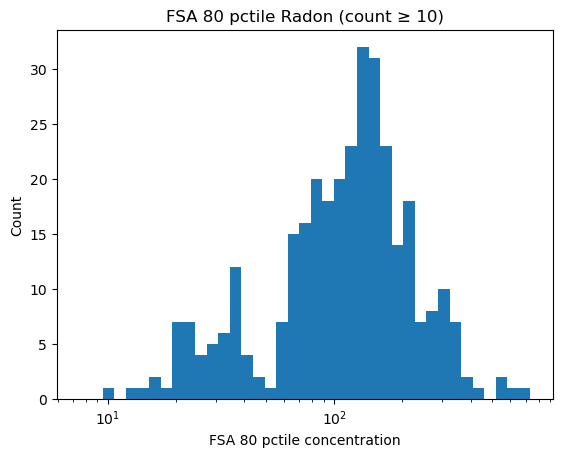

In [49]:
cutoff = 10
subset = fsa_stats[fsa_stats["count"] >= cutoff]["p80"]

bins = np.logspace(
    np.log10(subset.min()),
    np.log10(subset.max()),
    40
)


plt.hist(subset, bins=bins)
plt.xscale("log")
plt.xlabel("FSA 80 pctile concentration")
plt.ylabel("Count")
plt.title(f"FSA 80 pctile Radon (count ≥ {cutoff})")
plt.show()

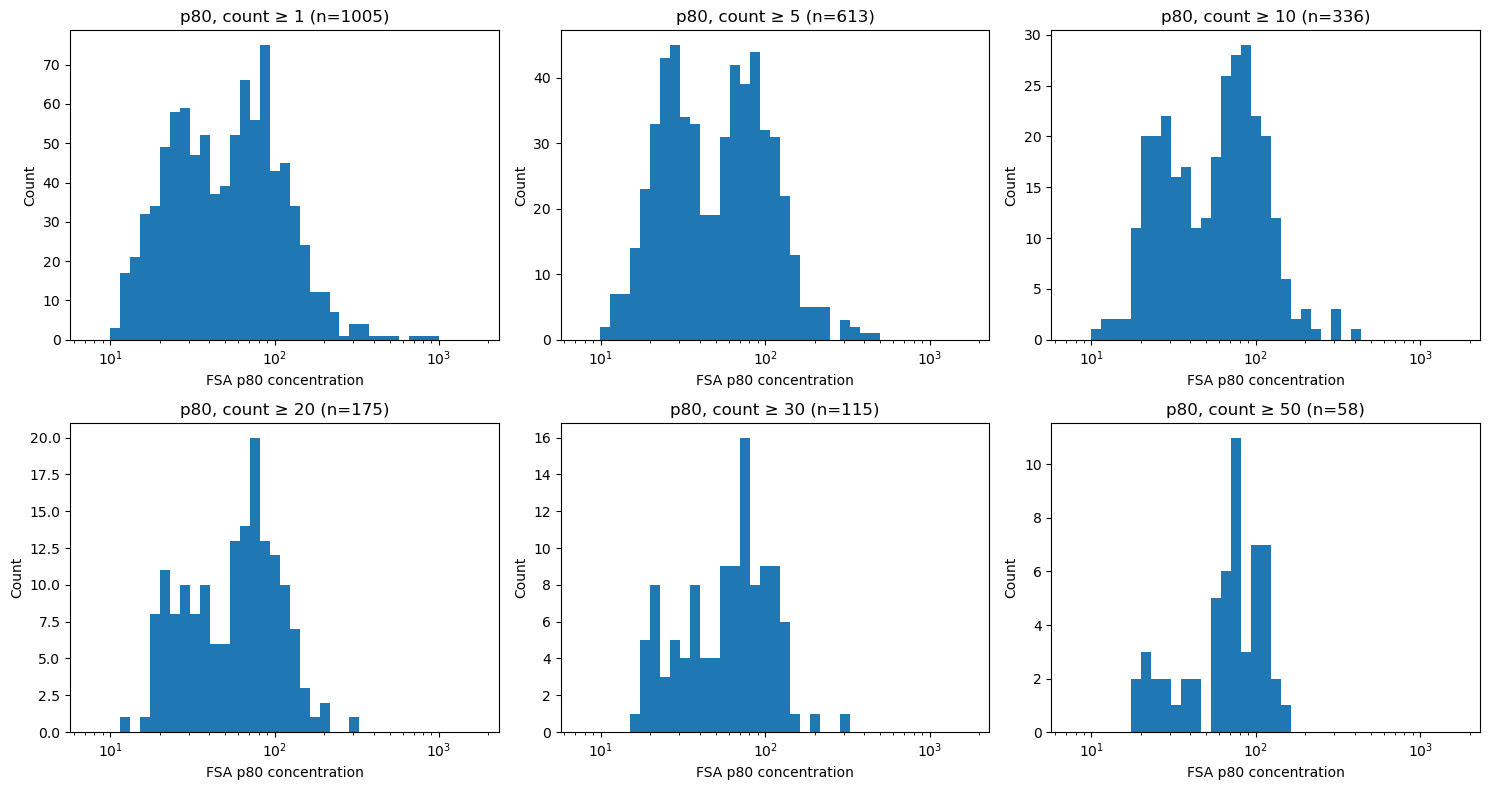

In [50]:
cutoffs = [1, 5, 10, 20, 30, 50]

all_p80s = fsa_stats["p80"]

bins = np.logspace(
    np.log10(all_p80s.min()),
    np.log10(all_p80s.max()),
    40
)

ncols = 3
nrows = int(np.ceil(len(cutoffs) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, cutoff in enumerate(cutoffs):
    ax = axes[i]
    
    subset = fsa_stats[fsa_stats["count"] >= cutoff]["median"]
    
    ax.hist(subset, bins=bins)
    ax.set_xscale("log")
    ax.set_title(f"p80, count ≥ {cutoff} (n={len(subset)})")
    ax.set_xlabel("FSA p80 concentration")
    ax.set_ylabel("Count")

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

OK! even with the 80-th percentile, there is still a clear bi-modal distribution of radon concentration. And that is true regardless of N.  So, that is kinda awesome!

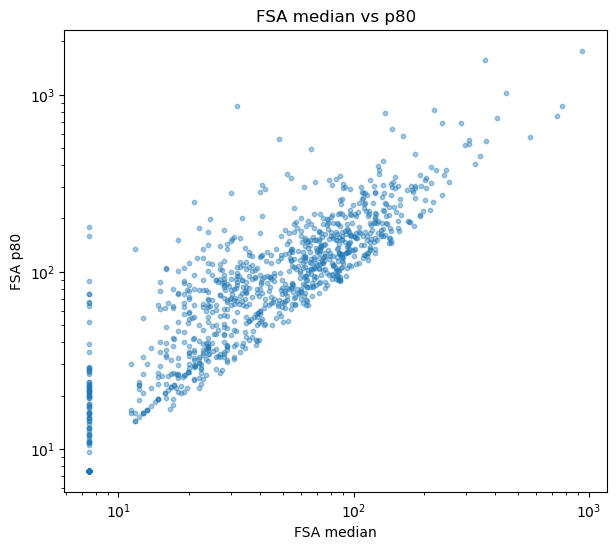

In [54]:

plt.figure(figsize=(7,6))

plt.scatter(
    fsa_stats["median"],
    fsa_stats["p80"],
    s=10,           # small marker size
    alpha=0.4       # transparency to reduce overplotting
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("FSA median")
plt.ylabel("FSA p80")
plt.title("FSA median vs p80")

plt.show()

Are there two groups really here?  

In [57]:

X = np.column_stack([
    np.log(fsa_stats["median"]),
    np.log(fsa_stats["p80"])
])

In [58]:

gmm1 = GaussianMixture(n_components=1, random_state=0)
gmm2 = GaussianMixture(n_components=2, random_state=0)

gmm1.fit(X)
gmm2.fit(X)

bic1 = gmm1.bic(X)
bic2 = gmm2.bic(X)

print("BIC (1 component):", bic1)
print("BIC (2 components):", bic2)

BIC (1 component): 4153.747758958291
BIC (2 components): 3939.728067254546


c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to 

OK, maybe there are not two sharply separated FSA types, but the joint distribution is not well-described by a single elliptical Gaussian 

ValueError: 'c' argument has 889 elements, which is inconsistent with 'x' and 'y' with size 1005.

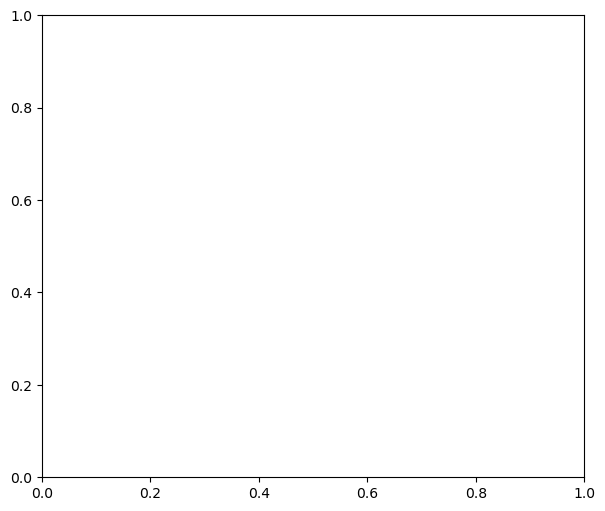

In [71]:
labels = gmm2.predict(X)

plt.figure(figsize=(7,6))
plt.scatter(
    fsa_stats["median"],
    fsa_stats["p80"],
    c=labels,
    s=10,
    cmap="coolwarm",
    alpha=0.5
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("median")
plt.ylabel("p80")
plt.show()

Hmmm, not convincing at all!  BUT I still feel like I see something

We need to get rid of those median == 7.5 points! 

In [60]:
mask = fsa_stats["median"] > 7.5
fsa_filtered = fsa_stats[mask]

X_filtered = np.column_stack([
    np.log(fsa_filtered["median"]),
    np.log(fsa_filtered["p80"])
])



gmm1 = GaussianMixture(n_components=1, random_state=0)
gmm2 = GaussianMixture(n_components=2, random_state=0)

gmm1.fit(X_filtered)
gmm2.fit(X_filtered)

bic1 = gmm1.bic(X_filtered)
bic2 = gmm2.bic(X_filtered)

print("BIC (1 component):", bic1)
print("BIC (2 components):", bic2)
print("ΔBIC:", bic1 - bic2)

BIC (1 component): 3136.514641725115
BIC (2 components): 2979.6616891067365
ΔBIC: 156.85295261837837


c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


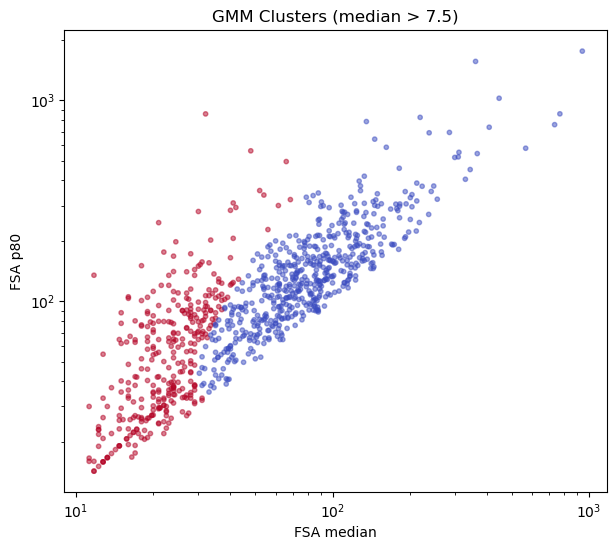

In [61]:
labels = gmm2.predict(X_filtered)


plt.figure(figsize=(7,6))

plt.scatter(
    fsa_filtered["median"],
    fsa_filtered["p80"],
    c=labels,
    s=10,
    alpha=0.5,
    cmap="coolwarm"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("FSA median")
plt.ylabel("FSA p80")
plt.title("GMM Clusters (median > 7.5)")
plt.show()

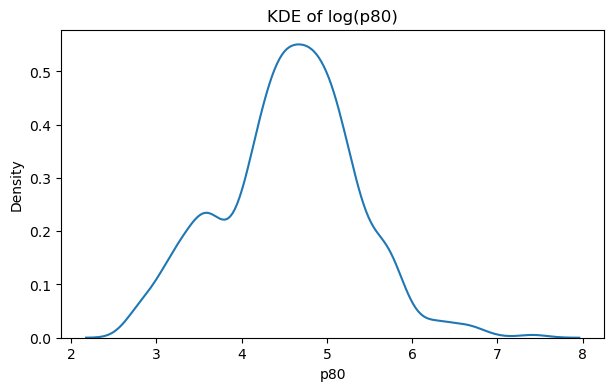

In [63]:

log_p80 = np.log(fsa_filtered["p80"])

plt.figure(figsize=(7,4))
sns.kdeplot(log_p80, bw_adjust=0.8)
plt.title("KDE of log(p80)")
plt.show()

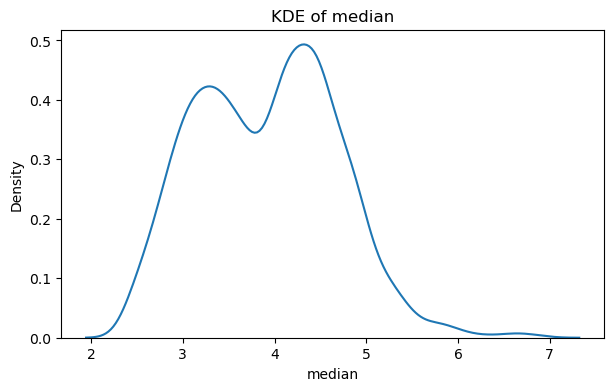

In [69]:
log_median = np.log(fsa_filtered["median"])

plt.figure(figsize=(7,4))
sns.kdeplot(log_median, bw_adjust=0.8)
plt.title("KDE of median")
plt.show()

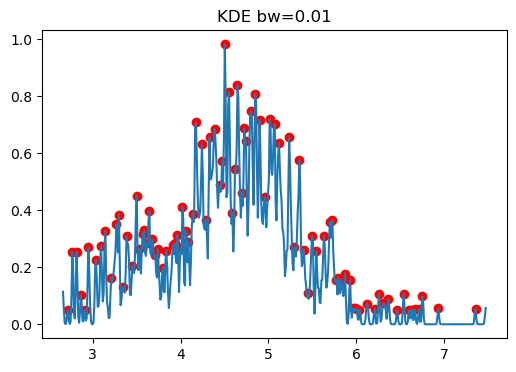

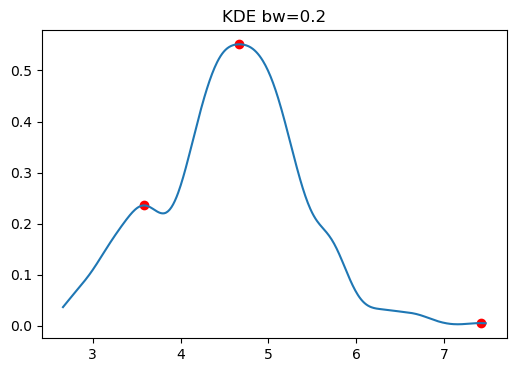

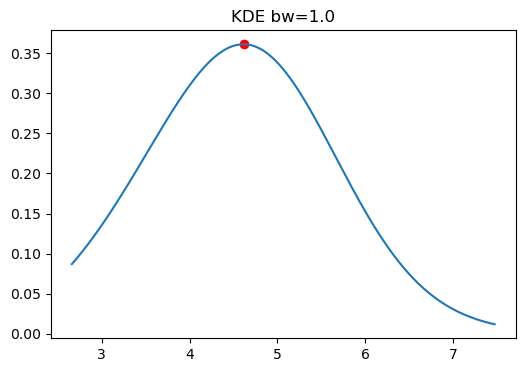

In [68]:
kde = gaussian_kde(log_p80)
xs = np.linspace(log_p80.min(), log_p80.max(), 500)
density = kde(xs)



log_p80 = np.log(fsa_filtered["p80"])

xs = np.linspace(log_p80.min(), log_p80.max(), 500)

for bw in [0.01, 0.2, 1.0]:
    kde = gaussian_kde(log_p80, bw_method=bw)
    density = kde(xs)

    peaks, _ = find_peaks(density)
    
    plt.figure(figsize=(6,4))
    plt.plot(xs, density)
    plt.scatter(xs[peaks], density[peaks], color="red")
    plt.title(f"KDE bw={bw}")
    plt.show()

hmmm, i'm confused about whether we have two tyopes of FSAs or not...

In [70]:
X = np.column_stack([
    np.log(fsa_filtered["median"]),
    np.log(fsa_filtered["p80"])
])


bics = []
components = [1, 2, 3, 4]

for k in components:
    gmm = GaussianMixture(n_components=k, random_state=0)
    gmm.fit(X)
    bics.append(gmm.bic(X))

for k, bic in zip(components, bics):
    print(f"{k} components: BIC = {bic}")

print("\nΔBICs relative to k=1:")
for k, bic in zip(components[1:], bics[1:]):
    print(f"{k} vs 1: {bics[0] - bic}")

1 components: BIC = 3136.514641725115
2 components: BIC = 2979.6616891067365
3 components: BIC = 2966.764010946724
4 components: BIC = 2926.3568996329614

ΔBICs relative to k=1:
2 vs 1: 156.85295261837837
3 vs 1: 169.75063077839104
4 vs 1: 210.1577420921535


c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\john\anaconda3\envs\erdos_ds_environment\Lib\site-pa

In [83]:
cutoff = 10

fsa_filtered = fsa_stats[fsa_stats["median"] > cutoff].copy()


X = np.column_stack([
    np.log(fsa_filtered["median"]),
    np.log(fsa_filtered["p80"])
])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# First principal component (the ridge direction)
z = X_pca[:, 0]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.91625024 0.08374976]


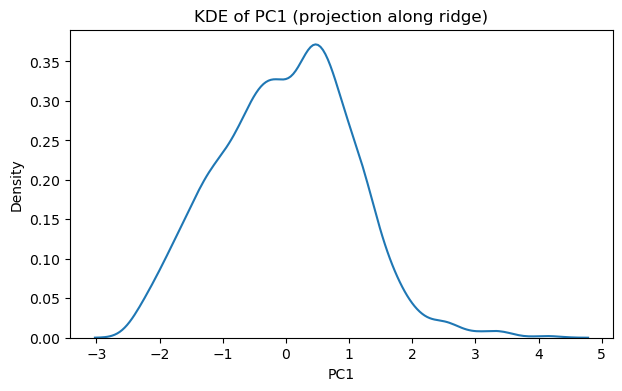

In [84]:
plt.figure(figsize=(7,4))
sns.kdeplot(z, bw_adjust=0.8)
plt.title("KDE of PC1 (projection along ridge)")
plt.xlabel("PC1")
plt.show()

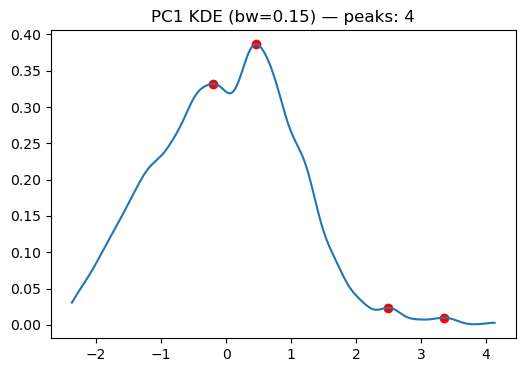

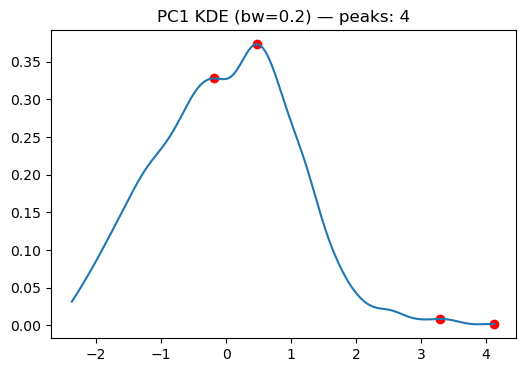

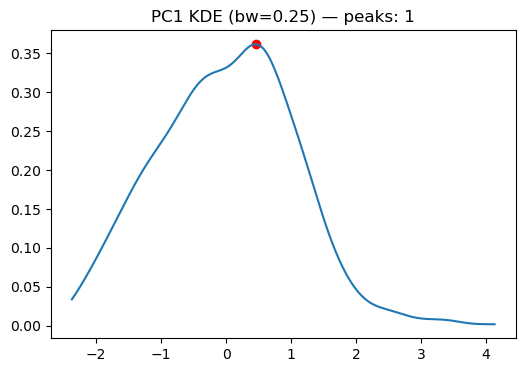

In [93]:


xs = np.linspace(z.min(), z.max(), 500)

for bw in [0.15, 0.2, 0.25]:
    kde = gaussian_kde(z, bw_method=bw)
    density = kde(xs)

    peaks, _ = find_peaks(density)

    plt.figure(figsize=(6,4))
    plt.plot(xs, density)
    plt.scatter(xs[peaks], density[peaks], color="red")
    plt.title(f"PC1 KDE (bw={bw}) — peaks: {len(peaks)}")
    plt.show()

There is a continuous geological gradient of radon in FSA across Canada.

FSAs cluster in two common exposure ranges:  below 50 and above 50

But no sharp threshold separates them.

In [52]:
fsa_province = df.groupby("fsa")["provinceterritory"].first()

fsa_stats = fsa_stats.join(fsa_province)

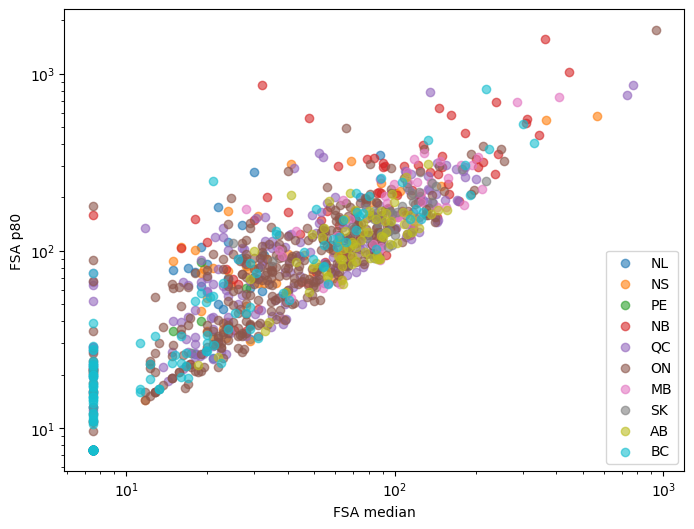

In [53]:

provinces = fsa_stats["provinceterritory"].unique()

plt.figure(figsize=(8,6))

for prov in provinces:
    subset = fsa_stats[fsa_stats["provinceterritory"] == prov]
    plt.scatter(subset["median"], subset["p80"], label=prov, alpha=0.6)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("FSA median")
plt.ylabel("FSA p80")
plt.legend()
plt.show()

How does variability look in the FSAs?

In [94]:
fsa_stats["count"].describe()

count    1005.000000
mean       13.011940
std        19.112944
min         2.000000
25%         3.000000
50%         6.000000
75%        13.000000
max       175.000000
Name: count, dtype: float64

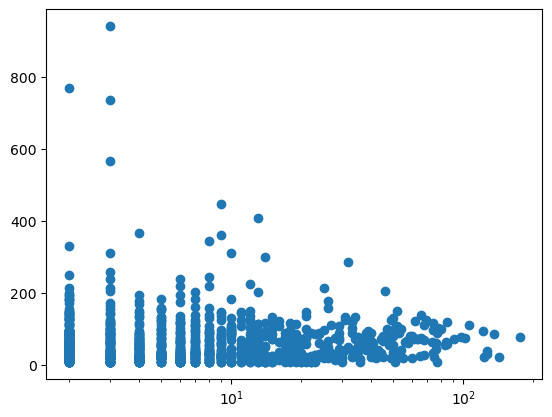

In [95]:
plt.scatter(fsa_stats["count"], fsa_stats["median"])
plt.xscale("log")
plt.show()

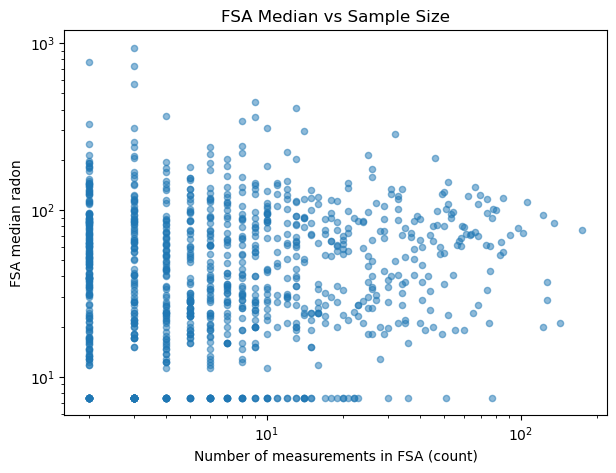

In [96]:

plt.figure(figsize=(7,5))
plt.scatter(
    fsa_stats["count"],
    fsa_stats["median"],
    alpha=0.5,
    s=20
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of measurements in FSA (count)")
plt.ylabel("FSA median radon")
plt.title("FSA Median vs Sample Size")
plt.show()

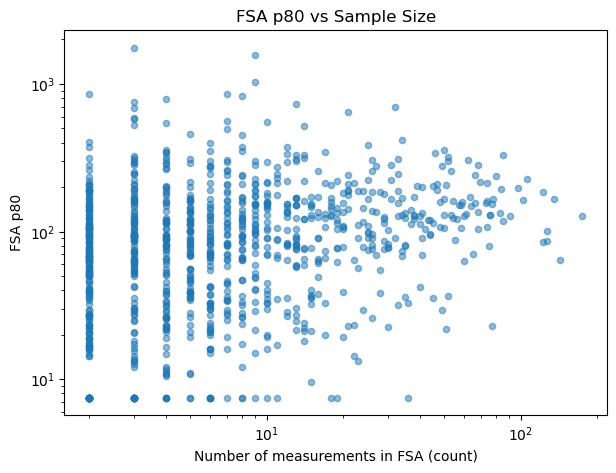

In [97]:
plt.figure(figsize=(7,5))
plt.scatter(
    fsa_stats["count"],
    fsa_stats["p80"],
    alpha=0.5,
    s=20
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of measurements in FSA (count)")
plt.ylabel("FSA p80")
plt.title("FSA p80 vs Sample Size")
plt.show()

Separation of p80 and median continues as FSA count increases (as we saw earlier.)

In [98]:
fsa_std = df.groupby("fsa")["concentration"].std()

fsa_stats["std"] = fsa_std

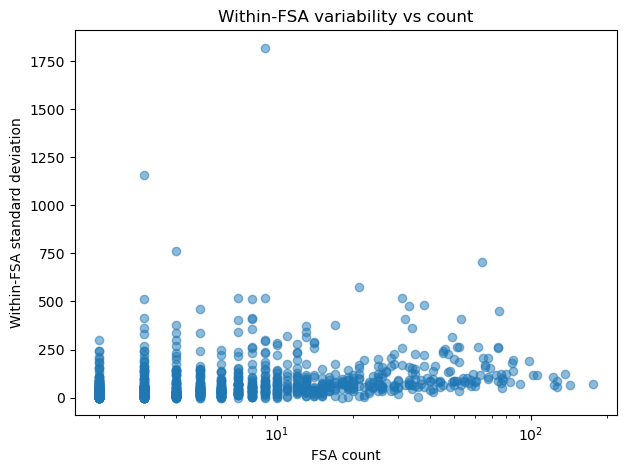

In [99]:
plt.figure(figsize=(7,5))
plt.scatter(
    fsa_stats["count"],
    fsa_stats["std"],
    alpha=0.5
)

plt.xscale("log")
plt.xlabel("FSA count")
plt.ylabel("Within-FSA standard deviation")
plt.title("Within-FSA variability vs count")
plt.show()

In [100]:
fsa_stats["se_mean"] = fsa_stats["std"] / np.sqrt(fsa_stats["count"])

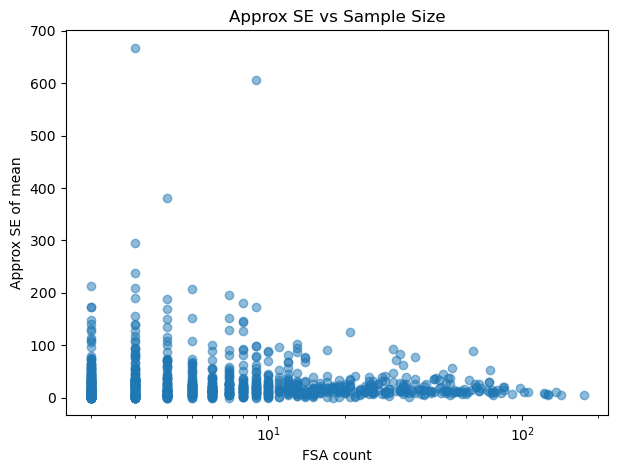

In [101]:
plt.figure(figsize=(7,5))
plt.scatter(
    fsa_stats["count"],
    fsa_stats["se_mean"],
    alpha=0.5
)

plt.xscale("log")
plt.xlabel("FSA count")
plt.ylabel("Approx SE of mean")
plt.title("Approx SE vs Sample Size")
plt.show()

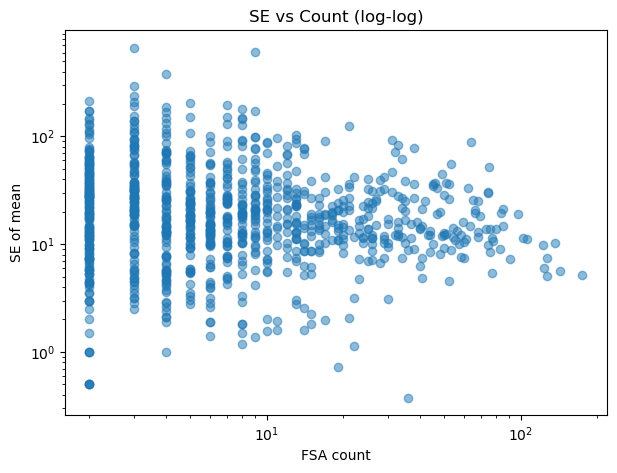

Estimated slope: -0.09717588580661765


In [103]:
fsa_stats["std"] = df.groupby("fsa")["concentration"].std()
fsa_stats["se_mean"] = fsa_stats["std"] / np.sqrt(fsa_stats["count"])


plt.figure(figsize=(7,5))
plt.scatter(
    fsa_stats["count"],
    fsa_stats["se_mean"],
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("FSA count")
plt.ylabel("SE of mean")
plt.title("SE vs Count (log-log)")
plt.show()

mask = (fsa_stats["count"] > 1) & (fsa_stats["se_mean"] > 0)

x = np.log(fsa_stats.loc[mask, "count"])
y = np.log(fsa_stats.loc[mask, "se_mean"])

slope, intercept = np.polyfit(x, y, 1)

print("Estimated slope:", slope)

Variability across FSAs doesn't decrease strongly with sampling size: 
That is, between-FSA differences dominate within-FSA sampling noise.

Radon exposure across Canadian FSAs:

Is highly skewed.

Shows density concentrations in two ranges.

Does NOT form discrete clusters.

Is NOT primarily driven by sampling instability.

Reflects real environmental heterogeneity.

The variation is continuous, structured, and persistent.

NOw, we need to figure out what explains the variation...
